# Aquifer Storage and Recovery: storing freshwater in a brackish aquifer

## Overview

A well **injects** treated freshwater into a brackish aquifer, the water spreads as a radial bubble, and
later the same well **pumps it back**. Mixing at the fresh/brackish interface -- mechanical dispersion
plus molecular/thermal diffusion -- means the recovered water salts up toward the end of pumping.
`gwtransport.radial_asr` solves the **exact** radial advection-dispersion for this push--pull schedule
(no grid, no numerical dispersion) and returns the recovered concentration; every computation here
includes molecular/thermal diffusion `D_m` (dominant for heat storage / ATES).

The flow is piecewise constant, so we use **irregular time bins** -- one bin for the whole injection,
finer bins through the recovery front, coarse on the flat plateaus -- far fewer steps than uniform daily
bins, with the same recovered mass. We show two things:

1. a **single** push--pull recovers most of the stored freshwater, and
2. over **repeated** cycles a freshwater buffer builds up, so the **recovery efficiency rises each cycle**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.radial_asr import infiltration_to_extraction

# --- Site, well, and water chemistry (chloride, mg/L) ---
SCREEN_HEIGHT = 20.0          # m, fully-penetrating well screen
POROSITY = 0.35
WELL_RADIUS = 0.3            # m
ALPHA_L = 0.5                # m, longitudinal dispersivity
MOLECULAR_DIFFUSIVITY = 0.6  # m2/day, molecular/thermal diffusion (heat/ATES scale), included throughout
C_BRACKISH = 1200.0          # native groundwater
C_FRESH = 50.0               # injected treated water
C_POTABLE = 300.0            # usable-water threshold

GEOM = {"pore_heights": SCREEN_HEIGHT, "porosity": POROSITY, "well_radius": WELL_RADIUS,
        "longitudinal_dispersivity": ALPHA_L, "molecular_diffusivity": MOLECULAR_DIFFUSIVITY}
N_QUAD = 40  # radial resident-profile quadrature (the cost driver when D_m > 0)
INJECTED = 1000.0 * 90       # m3 of freshwater stored per cycle


def push_pull():
    """One cycle as (flow_rate m3/day, duration days) segments, with IRREGULAR bins: a single bin for the
    constant 90-day injection, then recovery resolved fine (3 d) through the breakthrough front and coarse
    (15 d) on the flat plateaus -- 21 bins/cycle instead of 210 daily, with the same recovered mass."""
    inject = [(1000.0, 90.0)]
    recover = [(-800.0, 15.0)] * 4 + [(-800.0, 3.0)] * 15 + [(-800.0, 15.0)]  # 60 + 45 + 15 = 120 d
    return inject + recover


def schedule(n_cycles):
    """Build (flow rates, bin widths in days, time edges, cin) for n_cycles of push_pull()."""
    segs = push_pull() * n_cycles
    flow = np.array([rate for rate, _ in segs])
    dt = np.array([days for _, days in segs])
    tedges = pd.Timestamp("2021-01-01") + pd.to_timedelta(np.concatenate([[0.0], np.cumsum(dt)]), unit="D")
    cin = np.where(flow > 0, C_FRESH, C_BRACKISH)
    return flow, dt, tedges, cin

## 1. A single push--pull recovers most of the stored water

Inject 90,000 m³ of freshwater, then pump back. With **no quality threshold** -- recover everything that
comes up -- the chloride mass balance shows most of the stored freshwater returns; what is lost has
diffused beyond the recovery volume. The recovered water stays fresh, then salts up near the end as the
mixed edge of the bubble is drawn in. The breakthrough is drawn as steps -- the bin-average per
(irregular-width) time bin.

recovered 87% of the injected freshwater (no quality threshold)


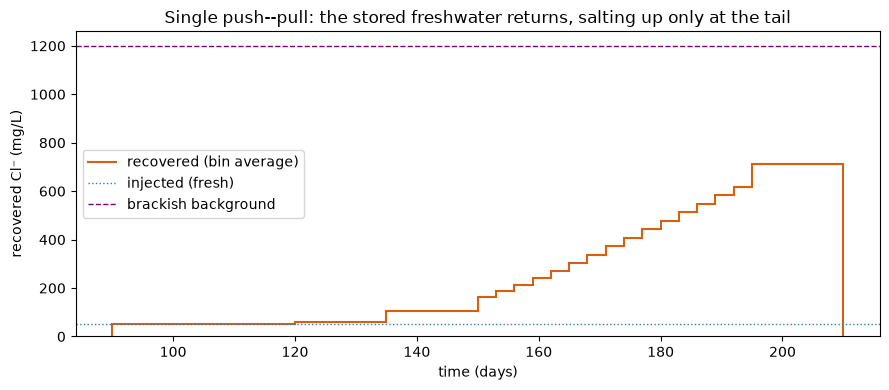

In [2]:
flow, dt, tedges, cin = schedule(1)
cout = infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges, background=C_BRACKISH, n_quad=N_QUAD, **GEOM,
)
ext = flow < 0
vol = np.abs(flow) * dt  # m3 recovered/injected per bin (irregular widths -> volume-weight everything)

recovered = np.sum(vol[ext] * (C_BRACKISH - cout[ext])) / np.sum(vol[flow > 0] * (C_BRACKISH - cin[flow > 0]))
print(f"recovered {100 * recovered:.0f}% of the injected freshwater (no quality threshold)")

day_edges = np.concatenate([[0.0], np.cumsum(dt)])      # bin edges in days
idx = np.where(ext)[0]
ext_edges = day_edges[idx[0]:idx[-1] + 2]               # edges bounding the (contiguous) recovery bins

fig, ax = plt.subplots(figsize=(9, 4))
ax.stairs(cout[ext], ext_edges, color="#d95f0e", lw=1.5, label="recovered (bin average)")
ax.axhline(C_FRESH, color="#2c7fb8", ls=":", lw=1, label="injected (fresh)")
ax.axhline(C_BRACKISH, color="#7a0177", ls="--", lw=1, label="brackish background")
ax.set_xlabel("time (days)"); ax.set_ylabel("recovered Cl⁻ (mg/L)")
ax.set_title("Single push--pull: the stored freshwater returns, salting up only at the tail")
ax.legend(); fig.tight_layout(); plt.show()

## 2. Repeated cycles build a buffer: recovery efficiency rises

Run the same cycle three times and apply the potable threshold (300 mg/L). The **recovery efficiency**
is the fraction of the injected volume recovered below the threshold. Freshwater left behind each cycle
freshens the aquifer around the well, so each cycle starts fresher and recovers a little more -- the
buffer effect real ASR schemes rely on to ramp up over their first years. Cycles are just the sign
pattern of `flow`; the engine composes them automatically.

cycle 1: recovery efficiency 67%
cycle 2: recovery efficiency 72%
cycle 3: recovery efficiency 75%


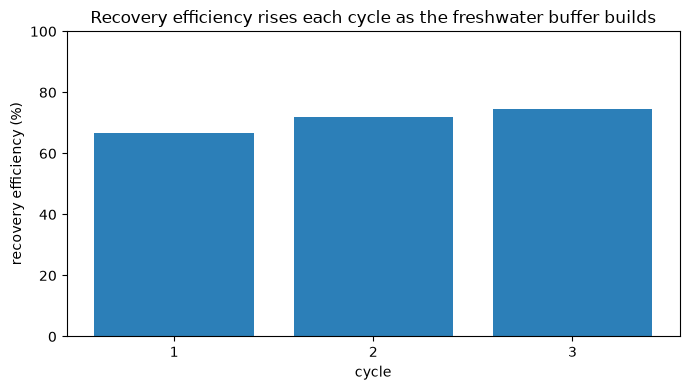

In [3]:
n_cycles = 3
flow, dt, tedges, cin = schedule(n_cycles)
cout = infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges, background=C_BRACKISH, n_quad=N_QUAD, **GEOM,
)
vol = np.abs(flow) * dt

cyc = len(push_pull())  # bins per cycle
re = []
for k in range(n_cycles):
    f, v, c = flow[k * cyc:(k + 1) * cyc], vol[k * cyc:(k + 1) * cyc], cout[k * cyc:(k + 1) * cyc]
    e = f < 0
    re.append(np.sum(v[e] * (c[e] < C_POTABLE)) / INJECTED)
for k, r in enumerate(re, 1):
    print(f"cycle {k}: recovery efficiency {100 * r:.0f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, n_cycles + 1), [100 * r for r in re], color="#2c7fb8")
ax.set_xlabel("cycle"); ax.set_ylabel("recovery efficiency (%)")
ax.set_xticks(range(1, n_cycles + 1)); ax.set_ylim(0, 100)
ax.set_title("Recovery efficiency rises each cycle as the freshwater buffer builds")
fig.tight_layout(); plt.show()

## Takeaways

- **A single push--pull recovers most of the stored freshwater** -- radial advection is reversible and
  only dispersion and diffusion smear the interface, so without a quality cutoff most of the mass comes
  back (it just salts up at the tail).
- **Recovery efficiency rises over cycles** -- freshwater left behind buffers the next cycle, the physical
  reason real ASR schemes improve over their first few years. The engine captures this exactly from the
  flow schedule alone, on irregular time bins, with molecular/thermal diffusion (`D_m`) throughout.

## References

- Tang, D. H., & Babu, D. K. (1979). Analytical solution of a velocity dependent dispersion problem.
  *Water Resources Research*, 15(6), 1471-1478. — the radial mechanical-dispersion (`D = alpha_L |u|`)
  injection solution in Airy functions.
- Aichi, M., & Akitaya, K. (2018). Analytical solution for a radial advection-dispersion equation
  including both mechanical dispersion and molecular diffusion ... from a well. *Hydrological Research
  Letters*, 12(3), 23-27. — the `D = alpha_L |u| + D_m` injection kernel under the same flux boundary.

These treat a single injection; the extraction dual and the multi-cycle push--pull composition shown here
are built on top of them.